# Examen SMUAIA03 - UE I.A et langage - 2025/2026

## Objectif

#### Dans cet exercice, votre tâche consiste d'abord à construire votre propre modèle basé sur un transformeur pour une tâche de Traduction Automatique Neuronale (NMT). L'objectif est :

  * #### Expérimenter différentes configurations lors de la construction du transformeur afin d'améliorer la qualité du modèle actuel (dont les performances sont mauvaises). Les métriques de performance, en particulier la Loss et le score BLEU sur l'ensemble de test, doivent être rapportées.

#### Ensuite, vous utiliserez un modèle pré-entraîné de la bibliothèque HuggingFace pour effectuer la même tâche. L'objectif ici est :

  * #### Comparer les performances (en termes de score BLEU uniquement) de votre modèle personnalisé avec celles du modèle HuggingFace pré-entraîné.


# Instructions

* ### Vous êtes autorisé à utiliser vos notes manuscrites personnelles et la documentation en ligne (par exemple, forums, documentation officielle). Cependant, toute tentative à l'utilisation d'outils d'intelligence artificielle (tels que ChatGPT) sera considérée comme une violation flagrante de l'intégrité de l'examen.
* ### Avant de soumettre votre travail, assurez-vous que toutes les cellules exécutées avec succès conservent leur sortie telle quelle (résultats affichés visibles).
* ### Veuillez nommer votre fichier de soumission comme suit : Exam-25-26-Nom-Prenom.
* ### Tous les membres de l'équipe (3 pers max) doivent soumettre le fichier en indiquant leur nom.


## Presentation
### Chaque équipe disposera de 10 minutes pour présenter son travail, les idées qu'elle a eues pour améliorer le projet et ce qui n'a pas fonctionné.

---
# Initialisation

Exécutez la cellule ci-dessous pour charger les paquets nécessaires et préparer l'environnement de développement.


In [4]:

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import copy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Pour reproduire les résultats, veuillez ne pas modifier ce paramètre en aucune circonstance.
seed = 42
torch.manual_seed(seed)

use_gpu = torch.cuda.is_available()
device = torch.device("cuda:0" if use_gpu else "cpu")
print("GPU available: {}".format(use_gpu))

GPU available: True


## Jeu de données

Vous utiliserez le jeu de données Patent Translation Resource (PatTR) qui contient des phrases appariées extraites de brevets. Il comprend plus de 18 000 000 paires de phrases français-anglais.

Le code ci-dessous téléchargera et décompressera le jeu de données PatTR. Il prendra ensuite les k premières paires de phrases anglais-français et les placera dans deux fichiers, l'un pour les phrases anglaises et l'autre pour les phrases françaises.


### Chargement et division du jeu de données

Maintenant que les données sont sur le système de fichiers local, vous pouvez les charger.

Rappelons que nous devons ajouter un préfixe aux phrases d'entrée afin d'indiquer au modèle que la tâche consiste à traduire ces phrases de l'anglais vers le français.

Lors de la division des données, nous ne conservons que 300 phrases pour l'ensemble de test. En général, ce n'est pas idéal ; nous souhaiterions un jeu de données plus grand afin d'évaluer les performances du modèle de manière aussi fiable que possible. Cependant, le score BLEU (la métrique que nous utiliserons pour évaluer le modèle) est assez coûteux à calculer, nous limitons donc la taille de l'ensemble de test pour des raisons de calcul.




In [5]:
# Charger les phrases appariées anglais-français
with open("dataset_en.txt", "r") as f:
  Xs = [s.strip() for s in f.readlines()]
with open("dataset_fr.txt", "r") as f:
  Ys = [s.strip() for s in f.readlines()]
n_samples = len(Xs)

# Diviser les données en ensembles d'entraînement, de validation et de test
train_val_index = round(0.90*n_samples)
val_test_index = round(0.97*n_samples)

xtrain, ytrain = Xs[:train_val_index], Ys[:train_val_index]
xvalid, yvalid = Xs[train_val_index:val_test_index], Ys[train_val_index:val_test_index]
xtest, ytest = Xs[val_test_index:], Ys[val_test_index:]

## Construire un modèle transformeur de zéro



In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

max_len = 100

class TransformerModel(nn.Module):
    def __init__(self, vocab_size, d_model=512, nhead=8, num_encoder_layers=6, num_decoder_layers=6, dim_feedforward=2048, max_len=max_len):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('positional_encoding', pe.unsqueeze(0))
        self.transformer = nn.Transformer(d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward, dropout=0.1)
        self.fc_out = nn.Linear(d_model, vocab_size)



    def forward(self, src, tgt):
        src_emb = self.embedding(src) + self.positional_encoding[:, :src.size(1)]
        tgt_emb = self.embedding(tgt) + self.positional_encoding[:, :tgt.size(1)]
        output = self.transformer(src_emb.permute(1, 0, 2), tgt_emb.permute(1, 0, 2))
        output = self.fc_out(output.permute(1, 0, 2))
        return output


tokenizer = AutoTokenizer.from_pretrained("t5-small")
vocab_size = tokenizer.vocab_size

built_transformer = TransformerModel(vocab_size).to(device)

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


## Tokeniser les données et créer les tenseurs et les dataloaders


In [7]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 32

# Tokeniser et convertir les entrées/cibles en tenseurs
train_encodings = tokenizer(xtrain, padding=True, truncation=True, return_tensors="pt", max_length=max_len)
train_labels = tokenizer(ytrain, padding=True, truncation=True, return_tensors="pt", max_length=max_len)
val_encodings = tokenizer(xvalid, padding=True, truncation=True, return_tensors="pt", max_length=max_len)
val_labels = tokenizer(yvalid, padding=True, truncation=True, return_tensors="pt", max_length=max_len)
test_encodings = tokenizer(xtest, padding=True, truncation=True, return_tensors="pt", max_length=max_len)
test_labels = tokenizer(ytest, padding=True, truncation=True, return_tensors="pt", max_length=max_len)

# Créer les TensorDatasets et DataLoaders
train_dataset = TensorDataset(train_encodings.input_ids, train_labels.input_ids)
val_dataset = TensorDataset(val_encodings.input_ids, val_labels.input_ids)
test_dataset = TensorDataset(test_encodings.input_ids, test_labels.input_ids)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [8]:
# Perte et optimiseur
from tqdm import tqdm

n_epoch = 20
learning_rate = 1e-4
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
optimizer_built_transformer = optim.Adam(built_transformer.parameters(), lr=learning_rate)
# Initialiser les poids du modèle
init_transformer_weights = copy.deepcopy(built_transformer.state_dict())

# Définir une fonction pour encapsuler la boucle d'entraînement principale
def train_model(model, init_weights, optimizer):
    train_loss_history = []
    valid_loss_history = []
    model.load_state_dict(init_weights)
    print("Start training\n\n")

    for epoch in tqdm(range(n_epoch), desc="Entrainement"):
        train_loss = 0
        train_n_iter = 0

        # Passer le modèle en mode entraînement
        model.train()
        torch.set_grad_enabled(True)

        # Itérer sur les données d'entraînement
        for x, y in train_loader:
            # Placer les tenseurs sur le device (CPU, ou GPU si disponible)
            x = x.to(device)
            y = y.to(device)

            # Réinitialiser le tampon de gradient
            optimizer.zero_grad()

            # Effectuer l'opération de propagation avant
            outputs = model(x, y[:, :-1])

            # Calculer la perte à l'aide de la fonction de perte
            loss = criterion(outputs.view(-1, outputs.shape[-1]), y[:, 1:].contiguous().view(-1))

            # Effectuer la rétropropagation
            loss.backward()

            # Effectuer l'étape d'optimisation
            optimizer.step()

            # Statistiques
            train_loss += loss.item()
            train_n_iter += 1

        valid_loss = 0
        valid_n_iter = 0

        # Passer le modèle en mode évaluation
        model.eval()
        with torch.no_grad():

            # Itérer sur les données de validation
            for x, y in val_loader:

                # Placer les tenseurs sur le device (CPU, ou GPU si disponible)
                x = x.to(device)
                y = y.to(device)

                # Effectuer l'opération de propagation avant
                outputs = model(x, y[:, :-1])

                # Calculer la perte à l'aide de la fonction de perte
                loss = criterion(outputs.view(-1, outputs.shape[-1]), y[:, 1:].contiguous().view(-1))

                # Statistiques
                valid_loss += loss.item()
                valid_n_iter += 1
        train_loss_history.append(train_loss / train_n_iter)
        valid_loss_history.append(valid_loss / valid_n_iter)

        print("Epoch {:2d} | Training loss = {:.5f} | Validation loss = {:.5f} "
              .format(epoch+1, (train_loss / train_n_iter), (valid_loss / valid_n_iter)))
    print('\n\nTraining complete')

    return train_loss_history, valid_loss_history


# Effectuer l'entraînement du modèle Transformeur
loss_history = train_model(built_transformer, init_transformer_weights, optimizer_built_transformer)

# Sauvegarder l'historique de perte pour plus tard
built_transformer_train_loss_history, built_transformer_valid_loss_history = loss_history

Start training




Entrainement:   5%|▌         | 1/20 [01:15<23:56, 75.62s/it]

Epoch  1 | Training loss = 5.54937 | Validation loss = 4.31703 


Entrainement:  10%|█         | 2/20 [02:32<22:52, 76.27s/it]

Epoch  2 | Training loss = 3.69313 | Validation loss = 3.05865 


...

Epoch 18 | Training loss = 0.01600 | Validation loss = 0.12887 


Entrainement:  95%|█████████▌| 19/20 [26:25<01:25, 85.58s/it]

Epoch 19 | Training loss = 0.01343 | Validation loss = 0.12716 


Entrainement: 100%|██████████| 20/20 [27:51<00:00, 83.55s/it]

Epoch 20 | Training loss = 0.01043 | Validation loss = 0.12263 


Training complete


## Tracer les courbes de perte d'entraînement et de validation



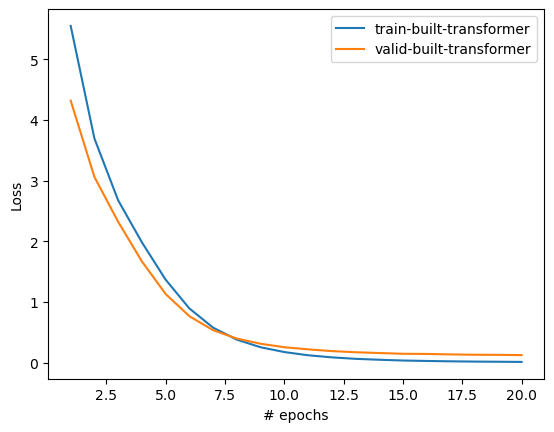

In [9]:
xaxis = range(1, n_epoch + 1)
plt.plot(xaxis, built_transformer_train_loss_history, label='train-built-transformer')
plt.plot(xaxis, built_transformer_valid_loss_history, label='valid-built-transformer')

plt.xlabel('# epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Le Score BLEU

Utilisez SacreBLEU, une implémentation de référence du BLEU avec des valeurs standardisées pour les paramètres.



In [10]:
from sacrebleu.metrics import BLEU
bleu = BLEU()

def get_bleu(prediction, reference):
    metric_output = bleu.corpus_score([prediction], [[reference]]) #the metric can take multiple references, not only one
    return metric_output

## Évaluation du modèle pré-entraîné : calcul de la perte et du score BLEU sur la partition de test


In [11]:
def test_model(model, test_loader, criterion, tokenizer):
    model.eval()
    total_loss = 0
    predictions = []
    references = []

    with torch.no_grad():
        for x, y in test_loader:
            # Placer les tenseurs sur le device (CPU, ou GPU si disponible)
            x = x.to(device)
            y = y.to(device)

            # Propagation avant
            outputs = model(x, y[:, :-1])
            loss = criterion(outputs.view(-1, outputs.shape[-1]), y[:, 1:].contiguous().view(-1))
            total_loss += loss.item()
            # Décoder les prédictions du modèle
            preds = torch.argmax(outputs, dim=-1)
            preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
            targets = tokenizer.batch_decode(y[:, 1:], skip_special_tokens=True)

            predictions.extend([pred for pred in preds])
            references.extend([ref for ref in targets])

            #print(references)
            inputs = tokenizer.batch_decode(x, skip_special_tokens=True)
            for inp, pred in zip(inputs, preds):
                print(f"EN : {inp}")
                print(f"FR : {pred}")
                print()

    # Calculer la perte moyenne
    avg_loss = total_loss / len(test_loader)

    return avg_loss, predictions, references


test_loss, predictions, references = test_model(built_transformer, test_loader, criterion, tokenizer)

#afficher la perte
print(f"The Transformer's test loss is {float(test_loss):2.3f}")

# calculer le score BLEU
bleu_score = bleu.corpus_score(predictions, [references])
print(f"Local Transformer BLEU score: {bleu_score}")

EN : Apparatus (40) for providing at an output (44) an output voltage (Vext) that is greater than an input voltage (Vsupply) that is applied to an input (43).
FR : areil (40) fournissant, au niveau d'une sortie (44), une tension de sortie (Vext) supérieure à une tension d'entrée (Voy) appliquée à une entrée (43).). pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré

EN : The apparatus (40) comprises an input charge pump stage (41.1) and an output charge pump stage (40.2).
FR : edit appareil (40) comporte un étage de pompe de charge d'entrée (42)) et un étage de pompe de charge de sortie (49)ente). pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré pré

EN : Each charge pump stage (40.1, 40

## Chargement d'un modèle Transformeur Pré-entraîné


Le code ci-dessous chargera un modèle T5-Small ainsi que le tokeniseur utilisé pour prétraiter ses données d'entrée.

Ce modèle T5-Small possède environ 60 millions de paramètres et a été pré-entraîné sur le jeu de données Colossal Clean Crawled Corpus (C4), un très grand jeu de données open-source collecté par crawling web automatisé. Il a été entraîné en parallèle sur plusieurs tâches de traitement du langage naturel, notamment la traduction, l'évaluation de la similarité entre deux phrases, le résumé de documents, etc. Cet entraînement a été réalisé de manière entièrement texte-à-texte, ce qui signifie que les entrées et sorties du modèle sont toujours du texte et qu'un préfixe est ajouté aux entrées pour identifier la tâche à effectuer.

Par exemple, indiquer qu'une phrase donnée doit être traduite de l'anglais vers le français peut se faire avec la structure d'entrée suivante :

"Translate English to French: [Phrase à traduire]"

Plus de détails sur le modèle T5-Small peuvent être trouvés dans ce [billet de blog](https://ai.googleblog.com/2020/02/exploring-transfer-learning-with-t5.html) et cet [article ArXiv](https://arxiv.org/pdf/1910.10683.pdf).

En plus du modèle, vous chargez également le tokeniseur associé au modèle T5-small, celui que vous avez déjà utilisé comme tokeniseur pour le transformeur construit. Ce tokeniseur a été utilisé pour prétraiter les entrées fournies au modèle ; ainsi, si nous voulons pouvoir prétraiter les données dans le format attendu par le modèle, nous devons utiliser le même tokeniseur.


In [18]:
# Charger le modèle T5-Small
pretrained_model = AutoModelForSeq2SeqLM.from_pretrained("t5-small")
pretrained_model.to(device)

# Charger le modèle T5-Small's tokenizer (already done but just as a reminder)
tokenizer = AutoTokenizer.from_pretrained("t5-small")

## Recharger les phrases appariées anglais-français
cette fois avec la préparation du prompt pour T5


In [19]:
with open("dataset_en.txt", "r") as f:
  Xs = [s.strip() for s in f.readlines()]
with open("dataset_fr.txt", "r") as f:
  Ys = [s.strip() for s in f.readlines()]
n_samples = len(Xs)

# Ajouter le préfixe de tâche aux entrées (préparation du prompt).
Xs = [f"translate English to French: {x}" for x in Xs]

# Diviser les données en ensembles d'entraînement, de validation et de test
train_val_index = round(0.90*n_samples)
val_test_index = round(0.97*n_samples)

xtrain, ytrain = Xs[:train_val_index], Ys[:train_val_index]
xvalid, yvalid = Xs[train_val_index:val_test_index], Ys[train_val_index:val_test_index]
xtest, ytest = Xs[val_test_index:], Ys[val_test_index:]

## Évaluation du modèle transformeur pré-entraîné



**Obtenir les prédictions du modèle puis calculer le score BLEU**

Utilisez le tokeniseur du modèle pour prétraiter les entrées dans le format attendu par le modèle.

L'obtention des prédictions du modèle se fait simplement via la fonction `generate()`. Un point important est que le comportement par défaut de la fonction generate est de générer seulement un petit bout de texte à la fois. Puisque les phrases de notre jeu de données sont assez longues, nous devons définir un `max_length` élevé pour nous assurer que le modèle peut effectivement générer les traductions attendues.

Les prédictions du modèle reviennent dans le même format que celui dans lequel nous avons fourni les entrées : sous forme de tenseurs Pytorch. Comme d'habitude, nous récupérons les données sous forme de tableau numpy et utilisons le tokeniseur pour revenir des tokens au texte.



In [ ]:
# Définir une fonction d'évaluation pour obtenir le score BLEU d'un modèle
def evaluate_model_bleu(model, tokenizer):
    model.eval()
    with torch.no_grad():
        predictions = []
        references = []
        for i, (x, y) in enumerate(zip(xtest, ytest)):

            # Encoder les entrées pour le modèle
            input_ids = tokenizer.encode(x, return_tensors="pt").to(device)

            # Obtenir la prédiction du modèle
            y_hat = model.generate(input_ids=input_ids, max_length=500)
            y_hat = np.array(y_hat[0].data.cpu())
            y_hat = tokenizer.decode(y_hat)

            # Ajouter l'exemple au calcul de la métrique (sacrebleu attend une liste de références)
            predictions.append(y_hat)
            references.append([y])

            if i < 5: # afficher l'entrée, la sortie et la référence pour les 5 premières instances
                print(f"------------------------------ Example {i} --------------------------")
                print(f"  Input: {x}")
                print(f"  Prediction: {y_hat}")
                print(f"  Label: {y}")

    return bleu.corpus_score(predictions, [references])

bleu_score = evaluate_model_bleu(pretrained_model, tokenizer)
print(f"Test BLEU score : {bleu_score}")

------------------------------ Example 0 --------------------------
  Input: translate English to French: Apparatus (40) for providing at an output (44) an output voltage (Vext) that is greater than an input voltage (Vsupply) that is applied to an input (43).
  Prediction: <pad> Appareils (40) pour fournir à une sortie (44) une tension de sortie (Vext) supérieure à une tension d'entrée (offre de V) appliquée à une entrée (43).</s>
  Label: Appareil (40) fournissant, au niveau d'une sortie (44), une tension de sortie (Vext) supérieure à une tension d'entrée (Vsupply) appliquée à une entrée (43).
------------------------------ Example 1 --------------------------
  Input: translate English to French: The apparatus (40) comprises an input charge pump stage (41.1) and an output charge pump stage (40.2).
  Prediction: <pad> L'appareil (40) comprend un étage de pompe à charge d'entrée (41,1) et un étage de pompe à charge d'entrée (40,2).</s>
  Label: Ledit appareil (40) comporte un étage de 

#  Rapportez ici toutes vos nouvelles configurations :

### Pour chaque nouvelle configuration, veuillez fournir les détails suivants :

* ### Modifications apportées : Précisez les changements apportés aux hyperparamètres, composants ou méthodes avec lesquels vous avez expérimenté.
* ### Justification : Expliquez le raisonnement ou l'intuition derrière le choix et l'expérimentation de la nouvelle configuration.
* ### Résultats : Rapportez les nouveaux scores de performance, notamment la perte sur le test et le score BLEU sur la partition de test. Comparez-les avec le meilleur score obtenu dans les configurations précédentes.

### Assurez-vous que votre réponse est bien structurée et clairement organisée !
### Si une nouvelle configuration ne s'exécute pas, fournissez quand même votre intuition et la configuration proposée (modifications à apporter), en justifiant vos choix, car cela compte également !


.........................................................................................

# Rapportez votre configuration de transformeur choisie et comparez-la au modèle pré-entraîné :

### Veuillez fournir les éléments suivants :

* ### Configuration choisie : Précisez la configuration finale du transformeur que vous avez sélectionnée après expérimentation.
* ### Scores BLEU : Comparez les scores BLEU obtenus avec votre propre modèle transformeur choisi et avec le modèle T5 pré-entraîné.


............................................................................................